In [15]:

""" 
This notebook defines a system of differential equations to model substrate depletion to for products with possible occurrence of trimming. 
"""

' \nThis notebook defines a system of differential equations to model substrate depletion to for products with possible occurrence of trimming. \n'

1. Import packages and libraries.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

2. Model Functions


In [17]:
def ode_system(t, y, params, n_prox_products, n_dist_products):
    """
    This function applies the differential equations to the system.
    INPUT: t - time, y = values, params - 2D array of parameters, 
           n_prox_products - number of proximal products,
           n_dist_products - number of distal products.

    OUTPUT: The change of substrate and products.
    """
    
    S = y[0]
    dPdt_prox = np.zeros(n_prox_products)
    dPdt_dist = np.zeros(n_dist_products)

    # Extract formation rates (diagonal) and trimming rates (upper triangle) for proximal
    k_formation_prox = np.diag(params[:n_prox_products, :n_prox_products])
    k_trimming_prox = np.triu(params[:n_prox_products, :n_prox_products], k=1)
    
    # Extract formation rates (diagonal) and trimming rates (upper triangle) for distal
    k_formation_dist = np.diag(params[n_prox_products:n_prox_products+n_dist_products, 
                                      n_prox_products:n_prox_products+n_dist_products])
    k_trimming_dist = np.triu(params[n_prox_products:n_prox_products+n_dist_products, 
                                     n_prox_products:n_prox_products+n_dist_products], k=1)
    
    # Substrate depletion (from both proximal and distal product formation)
    dSdt = -np.sum(k_formation_prox * S) - np.sum(k_formation_dist * S)

    # Proximal product formation from substrate
    for i in range(n_prox_products):
        dPdt_prox[i] = k_formation_prox[i] * S
    
    max_trim_distance_prox = n_prox_products - 1
    
    # Proximal trimming contributions
    for trim_distance in range(1, max_trim_distance_prox + 1):
        for i in range(n_prox_products - trim_distance):
            # y[i+1] is the i-th proximal product (offset by 1 for substrate)
            # Subtract loss from current product
            dPdt_prox[i] -= k_trimming_prox[i, i + trim_distance] * y[i + 1]
            # Add contribution to trimmed product
            dPdt_prox[i + trim_distance] += k_trimming_prox[i, i + trim_distance] * y[i + 1]

    # Distal product formation from substrate
    for i in range(n_dist_products):
        dPdt_dist[i] = k_formation_dist[i] * S
    
    max_trim_distance_dist = n_dist_products - 1
    
    # Distal trimming contributions
    for trim_distance in range(1, max_trim_distance_dist + 1):
        for i in range(n_dist_products - trim_distance):
            # y[n_prox_products + 1 + i] is the i-th distal product
            # Subtract loss from current product (i)
            dPdt_dist[i] -= k_trimming_dist[i, i + trim_distance] * y[n_prox_products + 1 + i]
            # Add contribution to trimmed product (i + trim_distance)
            dPdt_dist[i + trim_distance] += k_trimming_dist[i, i + trim_distance] * y[n_prox_products + 1 + i]

    return [dSdt] + dPdt_prox.tolist() + dPdt_dist.tolist()

def fitting_function(params_2d_flat, n_prox_products, n_dist_products, substrate_data, prox_product_data, dist_product_data, time_data, matrix_shape):
    """
    This function fits the given parameters to describe the relation between substrate depletion and product formation.
    INPUT: params_2d_flat - flattened 2D parameter array (for optimization),
           n_prox_products - number of proximal products,
           n_dist_products - number of distal products,
           substrate, proximal product data, distal product data, time points,
           matrix_shape - shape of the 2D parameter matrix
    OUTPUT: fitted residuals.
    """
    # Reshape back to 2D
    params_2d = params_2d_flat.reshape(matrix_shape)
    
    y0 = [substrate_data[0]] + [pd[0] for pd in prox_product_data] + [pd[0] for pd in dist_product_data]
    
    try:
        sol = solve_ivp(
            lambda t, y: ode_system(t, y, params_2d, n_prox_products, n_dist_products),
            [time_data[0], time_data[-1]],
            y0,
            t_eval=time_data,
            method='LSODA',
            rtol=1e-6,
            atol=1e-8,
            max_step=np.inf
        )
        
        if not sol.success:
            total_data_points = len(substrate_data) + sum(len(pd) for pd in prox_product_data) + sum(len(pd) for pd in dist_product_data)
            return np.ones(total_data_points) * 1e6
        
        y_predicted = sol.y
        residuals = [y_predicted[0] - substrate_data]
        
        for i in range(n_prox_products):
            residuals.append(y_predicted[i + 1] - prox_product_data[i])
        
        for i in range(n_dist_products):
            residuals.append(y_predicted[n_prox_products + 1 + i] - dist_product_data[i])
            
        return np.concatenate(residuals)
    except Exception as e:
        total_data_points = len(substrate_data) + sum(len(pd) for pd in prox_product_data) + sum(len(pd) for pd in dist_product_data)
        return np.ones(total_data_points) * 1e6

def r_squared(y_true, y_pred):
    """Calculate R² coefficient"""
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

def sum_squared_residuals(y_true, y_pred):
    """Calculate Sum of Squared Residuals (SSR)"""
    return np.sum((y_true - y_pred)**2)

def format_rate(rate, threshold=1e-7):
    """Format rate as 0 if below threshold, otherwise show value"""
    if abs(rate) < threshold:
        return 0.0
    return rate

3. CSV Import and data extraction


In [18]:
# === Main workflow ===
csv_file = input("Enter the path to the CSV file: ")
df = pd.read_csv(csv_file)

# Detect columns by header names
time_col = [col for col in df.columns if "time" in col.lower()][0]
substrate_col = [col for col in df.columns if "substrate" in col.lower()][0]
prox_product_cols = [col for col in df.columns if "proximal product" in col.lower()]
dist_product_cols = [col for col in df.columns if "distal product" in col.lower()]

# Extract data
time_data = df[time_col].values
substrate_data = df[substrate_col].values
prox_product_data = [df[col].values for col in prox_product_cols]
dist_product_data = [df[col].values for col in dist_product_cols]
n_prox_products = len(prox_product_cols)
n_dist_products = len(dist_product_cols)

print("Detected columns:")
print("Time column:", time_col)
print("Substrate column:", substrate_col)
print("Proximal Product columns:", prox_product_cols)
print("Distal Product columns:", dist_product_cols)
print(f"Number of time points: {len(time_data)}")
print(f"Time range: {time_data[0]} to {time_data[-1]}")

Detected columns:
Time column: Time
Substrate column: Substrate
Proximal Product columns: ['Proximal Product 1', 'Proximal Product 2', 'Proximal Product 3']
Distal Product columns: ['Distal Product 1', 'Distal Product 2']
Number of time points: 7
Time range: 0 to 2400


4. Initial parameter and model fitting
 

In [19]:
# Get initial guess from user
initial_guess = float(input("Enter an initial guess for cleavage rate (e.g., 0.01): "))

# Create 2D parameter matrix
# Structure: (n_prox + n_dist) x (n_prox + n_dist)
# Top-left block: proximal rates (diagonal + upper triangle)
# Bottom-right block: distal rates (diagonal + upper triangle)
matrix_size = n_prox_products + n_dist_products
params_init_2d = np.zeros((matrix_size, matrix_size))

# Fill proximal part (upper triangle including diagonal)
params_init_2d[:n_prox_products, :n_prox_products][np.triu_indices(n_prox_products)] = initial_guess

# Fill distal part (upper triangle including diagonal)
prox_offset = n_prox_products
params_init_2d[prox_offset:prox_offset+n_dist_products, 
               prox_offset:prox_offset+n_dist_products][np.triu_indices(n_dist_products)] = initial_guess

print("\nInitial parameter matrix (2D):")
print(params_init_2d)
print("\nProximal block (top-left):")
print(params_init_2d[:n_prox_products, :n_prox_products])
print("\nDistal block (bottom-right):")
print(params_init_2d[prox_offset:prox_offset+n_dist_products, prox_offset:prox_offset+n_dist_products])

# Calculate number of parameters
n_prox_params = n_prox_products + (n_prox_products * (n_prox_products - 1)) // 2
n_dist_params = n_dist_products + (n_dist_products * (n_dist_products - 1)) // 2
n_params = n_prox_params + n_dist_params

print(f"\nTotal parameters to fit: {n_params}")
print(f"  - Proximal formation rates (diagonal): {n_prox_products}")
print(f"  - Proximal trimming rates (upper triangle): {(n_prox_products * (n_prox_products - 1)) // 2}")
print(f"  - Distal formation rates (diagonal): {n_dist_products}")
print(f"  - Distal trimming rates (upper triangle): {(n_dist_products * (n_dist_products - 1)) // 2}")

# Flatten 2D matrix for optimization (least_squares requires 1D)
params_init_flat = params_init_2d.flatten()
matrix_shape = params_init_2d.shape

# Perform the fit
print("\nStarting optimization...")
print("This may take a few minutes depending on the complexity...")

# Add a callback to show progress
iteration_count = [0]
def callback(x):
    iteration_count[0] += 1
    if iteration_count[0] % 10 == 0:
        print(f"  Iteration {iteration_count[0]}...")

result = least_squares(
    fitting_function,
    params_init_flat,
    args=(n_prox_products, n_dist_products, substrate_data, prox_product_data, dist_product_data, time_data, matrix_shape),
    bounds=(0, 1),
    max_nfev=10000,  # Increased from 5000
    verbose=0,
)

# Reshape result back to 2D matrix
fitted_params_2d = result.x.reshape(matrix_shape)

print("\n=== Fitted Parameters (2D Matrix) ===")
print(fitted_params_2d)
print("\nProximal rates (top-left block):")
print(fitted_params_2d[:n_prox_products, :n_prox_products])
print("\nDistal rates (bottom-right block):")
prox_offset = n_prox_products
print(fitted_params_2d[prox_offset:prox_offset+n_dist_products, prox_offset:prox_offset+n_dist_products])

# Extract formation and trimming rates
k_formation_prox = np.diag(fitted_params_2d[:n_prox_products, :n_prox_products])
k_trimming_prox = np.triu(fitted_params_2d[:n_prox_products, :n_prox_products], k=1)
k_formation_dist = np.diag(fitted_params_2d[prox_offset:prox_offset+n_dist_products, 
                                            prox_offset:prox_offset+n_dist_products])
k_trimming_dist = np.triu(fitted_params_2d[prox_offset:prox_offset+n_dist_products, 
                                           prox_offset:prox_offset+n_dist_products], k=1)

# Generate smooth fitted curves with high sampling rate (20000 points)
sample_rate = 20000
time_fitted = np.linspace(min(time_data), 1.1*max(time_data), sample_rate)

print(f"\nGenerating smooth curves with {sample_rate} points...")

y0 = [substrate_data[0]] + [pd[0] for pd in prox_product_data] + [pd[0] for pd in dist_product_data]
sol = solve_ivp(
    lambda t, y: ode_system(t, y, fitted_params_2d, n_prox_products, n_dist_products),
    [time_fitted[0], time_fitted[-1]],
    y0,
    t_eval=time_fitted,
    method='LSODA',
    dense_output=True,
)

# Split predicted values for smooth curves
substrate_pred_fitted = sol.y[0]
prox_products_pred_fitted = [sol.y[i+1] for i in range(n_prox_products)]
dist_products_pred_fitted = [sol.y[n_prox_products+1+i] for i in range(n_dist_products)]

# Get predictions at data points for R² calculation
sol_data = solve_ivp(
    lambda t, y: ode_system(t, y, fitted_params_2d, n_prox_products, n_dist_products),
    [time_data[0], time_data[-1]],
    y0,
    t_eval=time_data,
    method='LSODA'
)
substrate_pred = sol_data.y[0]
prox_products_pred = [sol_data.y[i+1] for i in range(n_prox_products)]
dist_products_pred = [sol_data.y[n_prox_products+1+i] for i in range(n_dist_products)]

# Calculate R² and SSR
r2_values = []
ssr_values = []
r2_values.append(r_squared(substrate_data, substrate_pred))
ssr_values.append(sum_squared_residuals(substrate_data, substrate_pred))
for i in range(n_prox_products):
    r2_values.append(r_squared(prox_product_data[i], prox_products_pred[i]))
    ssr_values.append(sum_squared_residuals(prox_product_data[i], prox_products_pred[i]))
for i in range(n_dist_products):
    r2_values.append(r_squared(dist_product_data[i], dist_products_pred[i]))
    ssr_values.append(sum_squared_residuals(dist_product_data[i], dist_products_pred[i]))


Initial parameter matrix (2D):
[[0.01 0.01 0.01 0.   0.  ]
 [0.   0.01 0.01 0.   0.  ]
 [0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.01]
 [0.   0.   0.   0.   0.01]]

Proximal block (top-left):
[[0.01 0.01 0.01]
 [0.   0.01 0.01]
 [0.   0.   0.01]]

Distal block (bottom-right):
[[0.01 0.01]
 [0.   0.01]]

Total parameters to fit: 9
  - Proximal formation rates (diagonal): 3
  - Proximal trimming rates (upper triangle): 3
  - Distal formation rates (diagonal): 2
  - Distal trimming rates (upper triangle): 1

Starting optimization...
This may take a few minutes depending on the complexity...

=== Fitted Parameters (2D Matrix) ===
[[1.29939545e-02 1.61125800e-02 1.69861335e-02 3.05549173e-01
  9.99902169e-01]
 [9.96490677e-01 2.24504451e-08 1.19889304e-03 1.60087509e-01
  1.00000919e-10]
 [1.00000361e-10 9.99989538e-11 1.25620540e-08 1.00000000e-10
  1.00000000e-10]
 [1.00000000e-10 1.00000000e-10 1.00000000e-10 3.96473305e-03
  2.25773455e-04]
 [1.00000000e-10 1.00000000e-10 1.000

5. Printing and plotting the rates


=== Fitted Rates and Statistics ===
Total substrate depletion rate: 0.0240
R² (substrate): 0.9364, SSR (substrate): 0.0522

--- Proximal Formation Rates (Diagonal) ---
Proximal Product 1 formation rate: 0.012994
Proximal Product 2 formation rate: 0.000000
Proximal Product 3 formation rate: 0.000000

--- Proximal Trimming Rates (Upper Triangle) ---
Product 1 → Product 2 (distance 1) trimming rate: 0.016113
Product 1 → Product 3 (distance 2) trimming rate: 0.016986
Product 2 → Product 3 (distance 1) trimming rate: 0.001199

--- Distal Formation Rates (Diagonal) ---
Distal Product 1 formation rate: 0.003965
Distal Product 2 formation rate: 0.007041

--- Distal Trimming Rates (Upper Triangle) ---
Distal Product 1 → Distal Product 2 (distance 1) trimming rate: 0.000226

--- Proximal Product Fit Statistics ---
Proximal Product 1: R²=0.5245, SSR=0.0449
Proximal Product 2: R²=0.6615, SSR=0.0117
Proximal Product 3: R²=0.9541, SSR=0.0091

--- Distal Product Fit Statistics ---
Distal Product 1: 

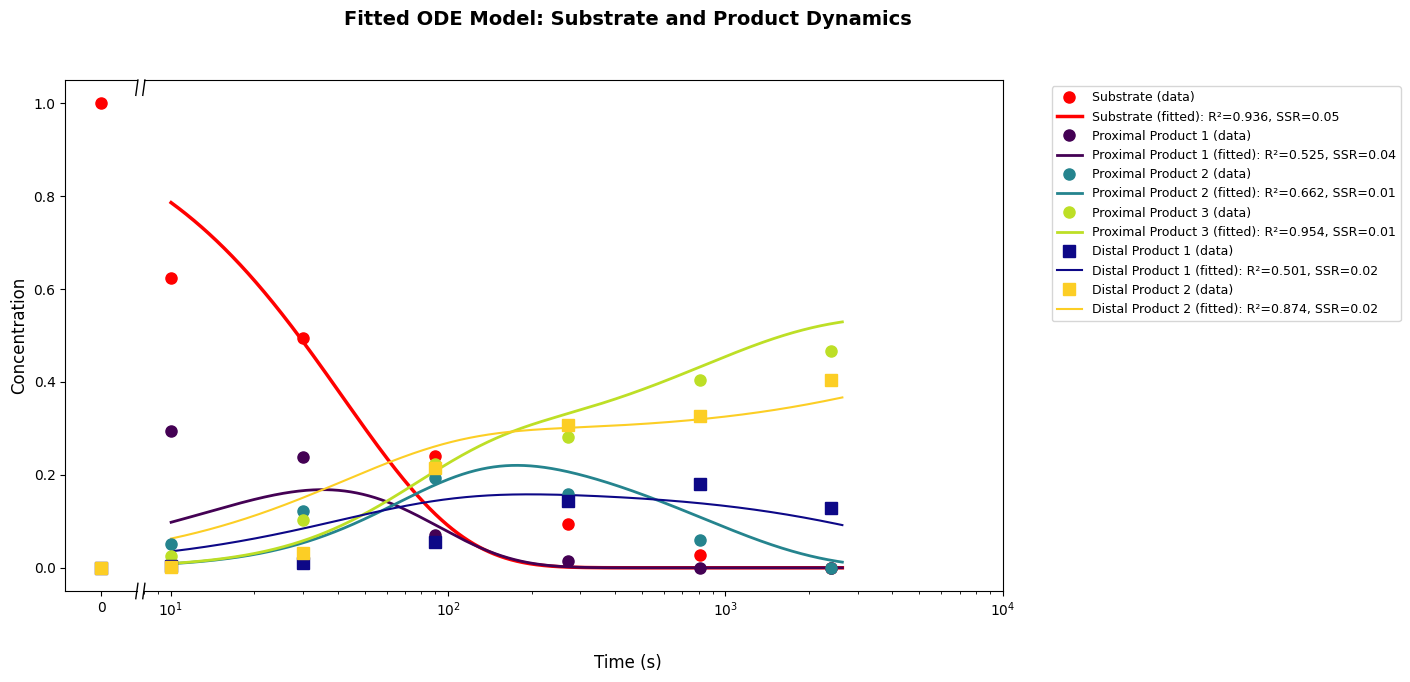

In [20]:
# === Print results ===
print("\n=== Fitted Rates and Statistics ===")
print(f"Total substrate depletion rate: {np.sum(k_formation_prox) + np.sum(k_formation_dist):.4f}")
print(f"R² (substrate): {r2_values[0]:.4f}, SSR (substrate): {ssr_values[0]:.4f}\n")

print("--- Proximal Formation Rates (Diagonal) ---")
for i in range(n_prox_products):
    formatted_rate = format_rate(k_formation_prox[i])
    print(f"Proximal Product {i+1} formation rate: {formatted_rate:.6f}")

print("\n--- Proximal Trimming Rates (Upper Triangle) ---")
for i in range(n_prox_products):
    for j in range(i+1, n_prox_products):
        trim_distance = j - i
        formatted_rate = format_rate(k_trimming_prox[i, j])
        print(f"Product {i+1} → Product {j+1} (distance {trim_distance}) trimming rate: {formatted_rate:.6f}")

print("\n--- Distal Formation Rates (Diagonal) ---")
for i in range(n_dist_products):
    formatted_rate = format_rate(k_formation_dist[i])
    print(f"Distal Product {i+1} formation rate: {formatted_rate:.6f}")

print("\n--- Distal Trimming Rates (Upper Triangle) ---")
for i in range(n_dist_products):
    for j in range(i+1, n_dist_products):
        trim_distance = j - i
        formatted_rate = format_rate(k_trimming_dist[i, j])
        print(f"Distal Product {i+1} → Distal Product {j+1} (distance {trim_distance}) trimming rate: {formatted_rate:.6f}")

print("\n--- Proximal Product Fit Statistics ---")
for i in range(n_prox_products):
    print(f"Proximal Product {i+1}: R²={r2_values[i+1]:.4f}, SSR={ssr_values[i+1]:.4f}")

print("\n--- Distal Product Fit Statistics ---")
for i in range(n_dist_products):
    print(f"Distal Product {i+1}: R²={r2_values[n_prox_products+i+1]:.4f}, SSR={ssr_values[n_prox_products+i+1]:.4f}")

# === Plot with broken x-axis (linear + log) ===
# --- 1. Filter the fitted data ---
mask = time_fitted >= 10
t_fit_filtered = time_fitted[mask]

# Create the figure
# width_ratios: [1, 12] means ax1 is narrow, ax2 is wide
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, facecolor='w', 
                               figsize=(15, 7), 
                               gridspec_kw={'width_ratios': [1, 12]})

# REDUCE DISTANCE BETWEEN AXES: set wspace very low
plt.subplots_adjust(wspace=0.015) 

# --- 2. Plotting Logic ---
def plot_all(target_ax, is_log_axis):
    # Substrate
    target_ax.plot(time_data, substrate_data, 'o', color='red', markersize=8, zorder=5, label='Substrate (data)')
    if is_log_axis:
        target_ax.plot(t_fit_filtered, substrate_pred_fitted[mask], '-', color='red', linewidth=2.5,
                      label=f'Substrate (fitted): R²={r2_values[0]:.3f}, SSR={ssr_values[0]:.2f}')

    # Proximal Products
    colors_prox = plt.cm.viridis(np.linspace(0, 0.9, n_prox_products))
    for i in range(n_prox_products):
        target_ax.plot(time_data, prox_product_data[i], 'o', color=colors_prox[i], markersize=8, zorder=5,
                      label=f'Proximal Product {i+1} (data)')
        if is_log_axis:
            target_ax.plot(t_fit_filtered, prox_products_pred_fitted[i][mask], '-', color=colors_prox[i], linewidth=2,
                          label=f'Proximal Product {i+1} (fitted): R²={r2_values[i+1]:.3f}, SSR={ssr_values[i+1]:.2f}')

    # Distal Products
    colors_dist = plt.cm.plasma(np.linspace(0, 0.9, n_dist_products))
    for i in range(n_dist_products):
        idx = n_prox_products + i + 1
        target_ax.plot(time_data, dist_product_data[i], 's', color=colors_dist[i], markersize=8, zorder=5,
                      label=f'Distal Product {i+1} (data)')
        if is_log_axis:
            target_ax.plot(t_fit_filtered, dist_products_pred_fitted[i][mask], '-', color=colors_dist[i], linewidth=1.5,
                          label=f'Distal Product {i+1} (fitted): R²={r2_values[idx]:.3f}, SSR={ssr_values[idx]:.2f}')

plot_all(ax1, is_log_axis=False)
plot_all(ax2, is_log_axis=True)

# --- 3. Axis Configuration ---
ax1.set_xlim(-0.5, 0.5) 
ax1.set_xticks([0])
ax1.set_xticklabels(['0'])
ax1.set_ylabel("Concentration", fontsize=12)

ax2.set_xscale('log')
ax2.set_xlim(8, max(time_data) * 1.2) 
ax2.set_xticks([10, 100, 1000, 10000])

# --- 4. REDUCE DISTANCE BETWEEN BREAK MARKS ---
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

# 'd' controls the "size/spread" of the marks. 
# Decrease this number to make the marks smaller and closer together.
d = .015 

kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
# These plot the slashes on the right edge of ax1
ax1.plot((1-d, 1+d), (-d, +d), **kwargs) # bottom slash
ax1.plot((1-d, 1+d), (1-d-d, 1-d+d), **kwargs) # top slash (adjusted to be lower)
# Note: To move them closer vertically, you can change the second tuple to (-d/2, +d/2)

kwargs.update(transform=ax2.transAxes)  
# The divisor (12) must match your width_ratio to make the slashes look like the same angle
ax2.plot((-d/12, +d/12), (-d, +d), **kwargs) 
ax2.plot((-d/12, +d/12), (1-d-d, 1-d+d), **kwargs)

# --- 5. Labels and Legend ---
fig.suptitle("Fitted ODE Model: Substrate and Product Dynamics", fontsize=14, fontweight='bold')
fig.text(0.5, 0.04, "Time (s)", ha='center', fontsize=12)

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, frameon=True)

plt.subplots_adjust(right=0.75, bottom=0.15)

# Save the plot
save_path = input("\nEnter the path to save the plot (SVG or PDF, or press Enter to skip): ")
if save_path.strip():
    try:
        # Determine format from extension or default to PDF
        if save_path.lower().endswith('.svg'):
            save_format = 'svg'
            # For SVG, use path conversion
            import matplotlib
            matplotlib.rcParams['svg.fonttype'] = 'path'
        elif save_path.lower().endswith('.pdf'):
            save_format = 'pdf'
            # For PDF, embed fonts properly
            import matplotlib
            matplotlib.rcParams['pdf.fonttype'] = 42
        else:
            # Default to PDF if no extension
            save_path = save_path + '.pdf'
            save_format = 'pdf'
            import matplotlib
            matplotlib.rcParams['pdf.fonttype'] = 42
        
        plt.savefig(save_path, format=save_format, bbox_inches='tight', dpi=300)
        print(f"Plot saved to: {save_path}")
        if save_format == 'pdf':
            print("Note: PDF format preserves text as editable text in Affinity Designer")
        else:
            print("Note: Text has been converted to paths for compatibility")
    except PermissionError:
        print(f"Error: Permission denied. Cannot save to '{save_path}'.")
        print("Please check that:")
        print("  - You provided a file path (not just a directory)")
        print("  - You have write permissions for that location")
        print("  - The directory exists")
    except Exception as e:
        print(f"Error saving plot: {e}")
else:
    print("Skipping plot save.")

plt.show()

6. Export fitted data into CSV


In [21]:
# === Export Fitted Data to CSV ===
# Ask user for export path
export_path = input("\nEnter the path to save fitted data as CSV (or press Enter to skip): ")

if export_path.strip():
    try:
        # Add .csv extension if not provided
        if not export_path.lower().endswith('.csv'):
            export_path = export_path + '.csv'
        
        # Create a dictionary to hold all data
        export_data = {}
        
        # Add time column with original header name
        export_data[time_col] = time_fitted
        
        # Add substrate data with original header name
        export_data[substrate_col] = substrate_pred_fitted
        
        # Add proximal product data with original header names
        for i, col_name in enumerate(prox_product_cols):
            export_data[col_name] = prox_products_pred_fitted[i]
        
        # Add distal product data with original header names
        for i, col_name in enumerate(dist_product_cols):
            export_data[col_name] = dist_products_pred_fitted[i]
        
        # Create DataFrame and save to CSV
        df_export = pd.DataFrame(export_data)
        df_export.to_csv(export_path, index=False)
        
        print(f"Fitted data exported to: {export_path}")
        print(f"Total data points: {len(time_fitted)}")
        print(f"Columns: {list(export_data.keys())}")
        
    except PermissionError:
        print(f"Error: Permission denied. Cannot save to '{export_path}'.")
        print("Please check that you have write permissions for that location.")
    except Exception as e:
        print(f"Error exporting data: {e}")
else:
    print("Skipping data export.")

Fitted data exported to: C:\Users\uzair\OneDrive - Vilnius University\Documents\Ph.D. Research\New Gels Data\A_VS_G\Analyzed Data\A_V_G fitted cy5\A_V_G gel3 fitted cy5.csv
Total data points: 20000
Columns: ['Time', 'Substrate', 'Proximal Product 1', 'Proximal Product 2', 'Proximal Product 3', 'Distal Product 1', 'Distal Product 2']
